In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.patches as patches

In [19]:
# Crear un DataFrame de ejemplo con datos de clientes
columnas = ["Nro muestra", "Nro Jugada", 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
datos = [
    [1, 2170, 3, 4,	14,	21,	41,	58,	70,	83,	85,	93],
    [2, 2171, 2, 4,	29,	53,	55,	57,	64,	69,	76,	97],
    [3, 2172, 4, 21, 26, 30,	42,	48,	53,	65,	73,	87],
    [4, 2173, 8, 23,	26,	30,	36,	37,	44,	52,	62,	77],
    [5, 2174, 3, 18,	19,	22,	31,	39,	48,	51,	70,	86],
    [6, 2175, 14,	25,	33,	36,	46,	48,	53,	55,	81,	84],
    [7, 2176, 11,	27,	43,	59,	63,	65,	66,	74,	98,	99],
    [8, 2177, 0,	24,	35,	56,	61,	65,	71,	76,	92,	99],
    [9, 2178, 29,	31,	48,	55,	64,	65,	70,	81,	87,	94],
    [10,2179, 0,	8,	14,	26,	31,	34,	55,	66,	74,	96]
]

# Crear DataFrame
df = pd.DataFrame(datos, columns=columnas)
df

,Nro muestra,Nro Jugada,1,2,3,4,5,6,7,8,9,10
0,1,2170,3,4,14,21,41,58,70,83,85,93
1,2,2171,2,4,29,53,55,57,64,69,76,97
2,3,2172,4,21,26,30,42,48,53,65,73,87
3,4,2173,8,23,26,30,36,37,44,52,62,77
4,5,2174,3,18,19,22,31,39,48,51,70,86
5,6,2175,14,25,33,36,46,48,53,55,81,84
6,7,2176,11,27,43,59,63,65,66,74,98,99
7,8,2177,0,24,35,56,61,65,71,76,92,99
8,9,2178,29,31,48,55,64,65,70,81,87,94
9,10,2179,0,8,14,26,31,34,55,66,74,96


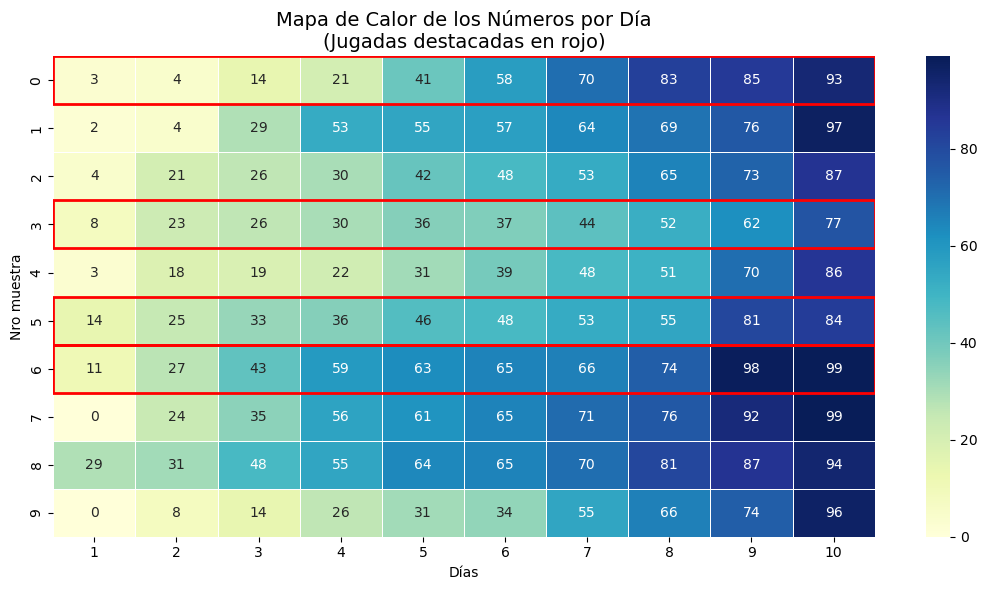

In [29]:
# Seleccionar solo los datos numéricos (de la jugada en adelante)
data = df.iloc[:, 2:]

# Crear mapa de calor
plt.figure(figsize=(11, 6))
ax = sns.heatmap(data, annot=True, cmap="YlGnBu", fmt="d", linewidths=0.5)

# Jugadas que queremos resaltar
jugadas_destacadas = [2170, 2173, 2175, 2176]

# Buscar las posiciones (índices) de esas jugadas
indices_destacados = df[df["Nro Jugada"].isin(jugadas_destacadas)].index.tolist()

# Añadir rectángulos rojos alrededor de las filas destacadas
for idx in indices_destacados:
    rect = patches.Rectangle(
        (0, idx),             # (x, y)
        data.shape[1],        # width
        1,                    # height
        fill=False,
        edgecolor='red',
        linewidth=2
    )
    ax.add_patch(rect)

# Añadir título y etiquetas
plt.title('Mapa de Calor de los Números por Día\n(Jugadas destacadas en rojo)', fontsize=14)
plt.xlabel('Días')
plt.ylabel('Nro muestra')

plt.tight_layout()
plt.show()

In [31]:
#Código para estimar la probabilidad:

In [33]:
import random

# Tus 5 números elegidos (pueden ser los que quieras)
tus_numeros = {4, 14, 21, 58, 70}

# Definir universo (1 a 99 por ejemplo)
universo = list(range(1, 100))

# Simular sorteos
total_sorteos = 100000
aciertos_totales = 0

for _ in range(total_sorteos):
    sorteo = set(random.sample(universo, 10))
    if tus_numeros.issubset(sorteo):  # Si todos los tuyos están en el sorteo
        aciertos_totales += 1

# Calcular probabilidad empírica
probabilidad = aciertos_totales / total_sorteos

print(f"Probabilidad estimada de que salgan tus 5 números: {probabilidad:.8f}")

Probabilidad estimada de que salgan tus 5 números: 0.00000000


In [35]:
#Ver cuántas veces apareció cada número en los sorteos anteriores (en tus columnas 1 a 10).

📊 Frecuencia de aparición de cada número:
48    4
55    4
65    4
26    3
14    3
     ..
35    1
24    1
33    1
62    1
96    1
Name: count, Length: 65, dtype: int64


C:\Users\brent\AppData\Local\Temp\ipykernel_7608\3318282992.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=frecuencia.index, y=frecuencia.values, palette="viridis")


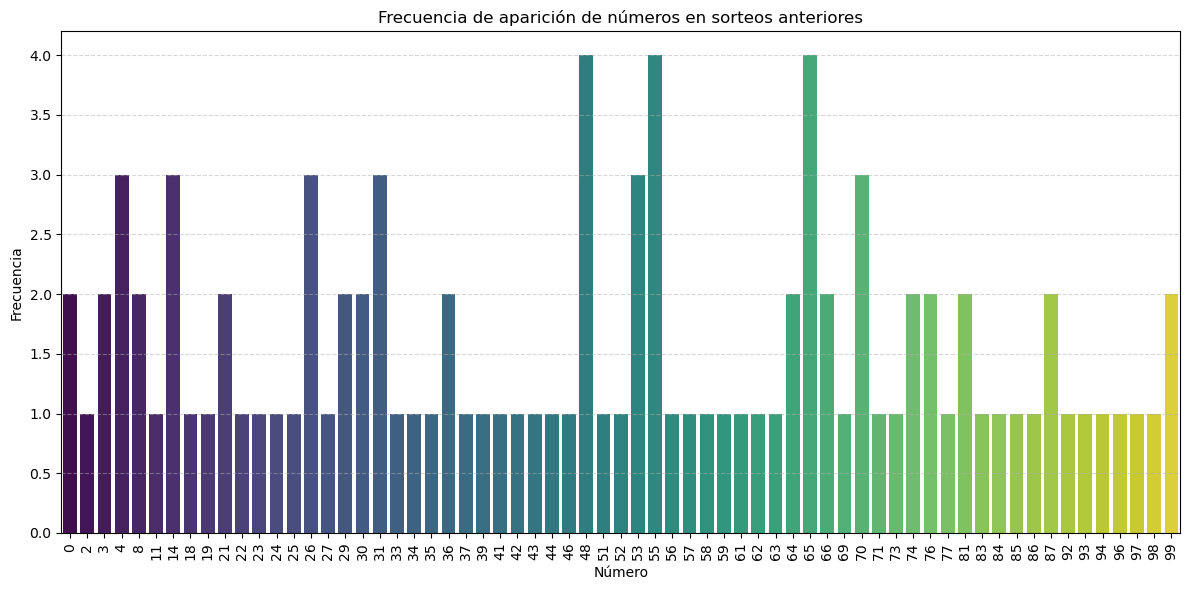

In [37]:
# Seleccionamos solo las columnas de los números sorteados
numeros_df = df.iloc[:, 2:]

# Aplanamos todos los números en una sola serie
todos_los_numeros = numeros_df.values.flatten()

# Creamos una tabla de frecuencia
frecuencia = pd.Series(todos_los_numeros).value_counts().sort_values(ascending=False)

# Mostrar tabla
print("📊 Frecuencia de aparición de cada número:")
print(frecuencia)

# Graficar
plt.figure(figsize=(12, 6))
sns.barplot(x=frecuencia.index, y=frecuencia.values, palette="viridis")
plt.title("Frecuencia de aparición de números en sorteos anteriores")
plt.xlabel("Número")
plt.ylabel("Frecuencia")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()